This training notebook is to test the output when certain variables (like the sentiment score) are removed

In [85]:
import pandas as pd
from sklearn.model_selection import train_test_split
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [86]:
df = pd.read_csv("../data/combined_data.csv", index_col="date", parse_dates=True)
df = df.dropna()
target = 'Close'
exog_cols = [
      'EMA_30', 'EMA_60', 'EMA_200',
      'rsi_14',
      'MACD', 'MACD_Signal', 'MACD_Histogram',
      'BB_Middle', 'BB_Upper', 'BB_Lower',
      'Momentum_10',

      'DTWEXBGS',   
      'OIL_PRICE',          
      'FEDFUNDS',           
      'CPIAUCSL',           

      'avg_sentiment_score',

      'Volume'
  ]

train, test = train_test_split(df, test_size=0.2, shuffle=False)
y_train, x_train = train[target], train[exog_cols]
y_test, x_test = test[target], test[exog_cols]

In [87]:
# Start with simpler model
arima_model = SARIMAX(y_train, exog=x_train, order=(1, 1, 0))  # Simpler model
fitted_arima = arima_model.fit(disp=False, maxiter=100)  # Add convergence controls

# Make predictions
arima_pred = fitted_arima.forecast(steps=len(y_test), exog=x_test)
arima_residuals = fitted_arima.resid  # Fix typo

C:\Users\hitae\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\hitae\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\hitae\AppData\Roaming\Python\Python312\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\hitae\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning

Evaluation Metrics:

In [88]:
from sklearn.metrics import mean_squared_error
from statsmodels.tools.eval_measures import rmse
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import pearsonr

In [89]:
mae = mean_absolute_error(y_test, arima_pred)
rmse = rmse(y_test, arima_pred)
mse = mean_squared_error(y_test, arima_pred)
r2 = r2_score(y_test, arima_pred)
pearson_corr, _ = pearsonr(y_test.values, arima_pred.values)

print(f"MAE: {mae}")
print(f"MSE: {mse}")
print(f"RMSE: {rmse}")
print(f"R2_SCORE: {r2}")
print(f"PEARSON CORRELATION: {pearson_corr}")

MAE: 4.7731203095060994
MSE: 27.28577627062317
RMSE: 5.2235788756965436
R2_SCORE: 0.9340704794446986
PEARSON CORRELATION: 0.9960982504357956


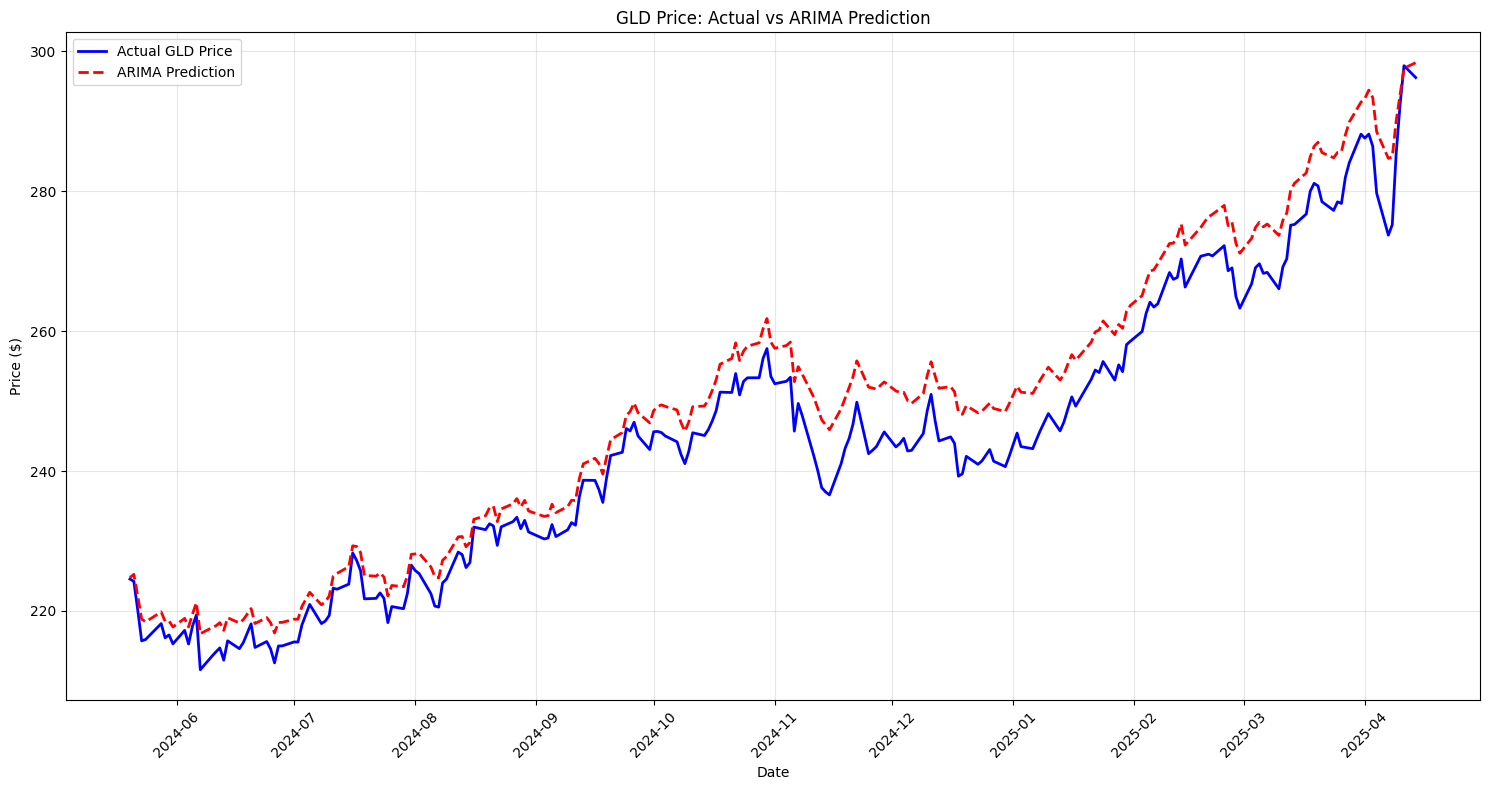

Test data shape: (226,)
Prediction shape: (226,)
Test date range: 2024-05-20 00:00:00 to 2025-04-14 00:00:00
Actual price range: $211.60 - $297.93
Predicted price range: $216.75 - $298.36


In [90]:
import matplotlib.pyplot as plt

# Create proper plot with aligned indices
plt.figure(figsize=(15, 8))

# Plot actual values
plt.plot(y_test.index, y_test.values, label='Actual GLD Price', color='blue', linewidth=2)

# Plot ARIMA predictions - align with test index
plt.plot(y_test.index, arima_pred.values, label='ARIMA Prediction', color='red', linewidth=2, linestyle='--')

plt.title('GLD Price: Actual vs ARIMA Prediction')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Also print some diagnostics
print(f"Test data shape: {y_test.shape}")
print(f"Prediction shape: {arima_pred.shape}")
print(f"Test date range: {y_test.index[0]} to {y_test.index[-1]}")
print(f"Actual price range: ${y_test.min():.2f} - ${y_test.max():.2f}")
print(f"Predicted price range: ${arima_pred.min():.2f} - ${arima_pred.max():.2f}")

### TESTING RESULTS:

#### Using All Metrics:
* MAE: 4.7731203095060994                   *//lower better*
* MSE: 27.28577627062317                    *//lower better (penalizes greater errors more than mae)*
* RMSE: 5.2235788756965436                  *//lower better (same units we are working in, as opposed to mse)*
* R2_SCORE: 0.9340704794446986              *//closer to 1 better*
* PEARSON CORRELATION: 0.9960982504357956   *//the closer to 1, the better trends are captures*

##### ANALYSIS: 
* This is the baseline to compare from

# ----------------------------------------------------------

#### No Macro data:
* MAE: 5.203945475852723                   *//lower better*
* MSE: 32.303134273517394                    *//lower better (penalizes greater errors more than mae)*
* RMSE: 5.6835846323880315                  *//lower better (same units we are working in, as opposed to mse)*
* R2_SCORE: 0.9219472396913454            *//closer to 1 better*
* PEARSON CORRELATION: 0.9959908196001588   *//the closer to 1, the better trends are captures*

##### ANALYSIS: 
* Overall values and correlation are worse
* Captures trends just about the same as all metrics

# ----------------------------------------------------------

#### No Macro data:
* MAE: 4.713275281606374                   *//lower better*
* MSE: 26.676142521041424                    *//lower better (penalizes greater errors more than mae)*
* RMSE: 5.164895209105546                  *//lower better (same units we are working in, as opposed to mse)*
* R2_SCORE: 0.9355435128825462            *//closer to 1 better*
* PEARSON CORRELATION: 0.9961023008936161   *//the closer to 1, the better trends are captures*

##### ANALYSIS: 
* Overall values and correlation are better than baseline
* Captures trends just about the same as baseline, with a slight increase
* This may have to do with the quality of sentiment data. May have to redo news data to make better